La función de Rastrigin de $n$ variables se define matemáticamente como:
$$f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10 \cos(2\pi x_i) \right]$$
Tiene un mínimo global en $\mathbf{x} = \mathbf{0}$ donde $f(\mathbf{0}) = 0$. 

In [7]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

In [2]:
def rastrigin(individual):
    n = len(individual)
    A = 10
    f_x = A * n + sum([(x**2 - A * np.cos(2 * np.pi * x)) for x in individual])
    return (f_x,)

### Algoritmo Genético con DEAP
Creamos los tipos de objetos necesarios (Fitness y Individuo) y registramos los operadores genéticos en el `toolbox`:
* **Individuos:** Vectores de números reales.
* **Evaluación:** Minimización de la función Rastrigin.
* **Selección:** Torneo.
* **Cruce:** Cruce de dos puntos (Two-point crossover).
* **Mutación:** Mutación gaussiana.

In [3]:
N_VARIABLES = 5 # Numero de dimensiones (variables)
BOUND_LOW, BOUND_UP = -5.12, 5.12 # Limites del espacio de búsqueda

# Pesos negativos (-1.0) indica que es un problema de MINIMIZACIÓN
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Atributo: Generador de números flotantes dentro de los límites
toolbox.register("attr_float", random.uniform, BOUND_LOW, BOUND_UP)

# Estructura del individuo y de la población
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=N_VARIABLES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Operadores genéticos
toolbox.register("evaluate", rastrigin)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1.0, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

In [6]:
def run_algoritmo():
    random.seed(42) # Semilla para reproducibilidad
    
    # Parámetros del AG
    pop = toolbox.population(n=100) # Población inicial
    cxpb = 0.7                      # Probabilidad de cruce
    mutpb = 0.2                     # Probabilidad de mutación
    ngen = 100                      # Número de generaciones

    # guardar el mejor individuo de todos
    hof = tools.HallOfFame(1)

    # Estadísticas para analizar la evolución
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # Decorador para asegurar que los límites no se violen tras el cruce/mutación
    def checkBounds(min_val, max_val):
        def decorator(func):
            def wrapper(*args, **kargs):
                offspring = func(*args, **kargs)
                for child in offspring:
                    for i in range(len(child)):
                        if child[i] > max_val:
                            child[i] = max_val
                        elif child[i] < min_val:
                            child[i] = min_val
                return offspring
            return wrapper
        return decorator

    toolbox.decorate("mate", checkBounds(BOUND_LOW, BOUND_UP))
    toolbox.decorate("mutate", checkBounds(BOUND_LOW, BOUND_UP))

    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=cxpb, mutpb=mutpb, 
                                   ngen=ngen, stats=stats, halloffame=hof, verbose=True)

    return hof[0], hof[0].fitness.values[0], log

best_ind, best_fit, log = run_algoritmo()
print(f"Mejor individuo (X): {[round(x, 4) for x in best_ind]}")
print(f"Valor mínimo de la función f(X): {best_fit:.6f}")

gen	nevals	min    	avg    
0  	100   	26.5291	92.8765
1  	74    	16.2218	71.9198
2  	83    	15.0013	56.5525
3  	80    	15.0013	43.1976
4  	73    	8.77627	33.0616
5  	77    	7.53982	25.4994
6  	74    	5.96954	18.4609
7  	81    	5.35205	12.5582
8  	89    	5.35205	9.69216
9  	78    	5.35205	8.65048
10 	82    	5.03386	8.75674
11 	80    	3.91574	7.21977
12 	63    	5.03386	7.87698
13 	78    	5.03386	7.1698 
14 	74    	3.94863	7.24626
15 	72    	3.94863	6.95687
16 	84    	3.8554 	8.23865
17 	69    	3.74683	6.97579
18 	74    	3.63044	7.05661
19 	73    	3.63044	6.34135
20 	89    	3.63044	6.89488
21 	83    	3.63044	5.39777
22 	78    	2.3253 	4.63089
23 	67    	2.3253 	5.90592
24 	77    	2.3253 	6.0576 
25 	79    	2.3253 	4.79257
26 	80    	2.32281	4.40571
27 	81    	2.32281	5.43784
28 	70    	2.32281	5.47945
29 	74    	2.32281	3.68839
30 	76    	2.32281	3.96772
31 	74    	2.32281	4.4852 
32 	67    	2.32281	4.91225
33 	79    	2.32281	5.13902
34 	83    	2.32281	4.78584
35 	72    	2.32281	4.12556
3

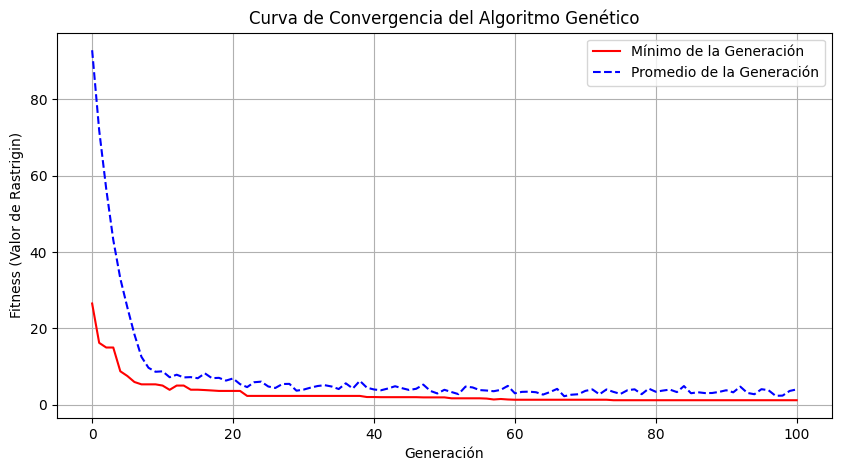

In [8]:
gen = log.select("gen")
fit_mins = log.select("min")
fit_avgs = log.select("avg")

plt.figure(figsize=(10, 5))
plt.plot(gen, fit_mins, label="Mínimo de la Generación", color='red')
plt.plot(gen, fit_avgs, label="Promedio de la Generación", color='blue', linestyle='--')
plt.xlabel("Generación")
plt.ylabel("Fitness (Valor de Rastrigin)")
plt.title("Curva de Convergencia del Algoritmo Genético")
plt.legend()
plt.grid(True)
plt.show()